<a href="https://colab.research.google.com/github/JorgePeje/test-python-utec/blob/main/Analisisdemorasoldadura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = [
["2025-09-08",3178,"PM1","Sideboard",1],
["2025-09-18",3174,"PM1","Parachoque",3.8],
["2025-09-21",3161,"PM2","Portapads",9.7],
["2025-09-19",3176,"PPM","Canopy",6.9],
["2025-09-19",3165,"PPM","Base Guardafango",1],
["2025-09-23",3164,"PM2","Viga longitudinal",4.3],
["2025-11-04",3192,"PPM","Canopy",2.3],
["2025-11-15",3198,"PM2","Piso tolva",5],
["2025-11-26",3197,"PM1","Viga longitudinal",5.8],
["2025-11-26",3191,"PM1","Guiador tolva",5],
["2025-12-22",3161,"PM1","Viga longitudinal",6],
["2025-12-25",3197,"PM2","Canopy",1],
["2026-01-11",3179,"PM1","Viga longitudinal",5.3],
["2026-01-14",3178,"PPM","Viga longitudinal",5.4],
["2026-01-22",3192,"PM2","Viga longitudinal",2.3],
["2026-02-28",3192,"PM1","Pin pivot tolva",4],
["2026-03-01",3193,"PM2","Canopy",3.8],
["2026-03-11",3180,"PM4","Parachoque",3.4],
["2026-03-13",3170,"PM1","Parachoque",3],
["2026-03-18",3166,"PPM","Parachoque",3],
]

df = pd.DataFrame(data, columns=["Fecha","Equipo","Tipo_PM","Tarea","Demora"])
df["Fecha"] = pd.to_datetime(df["Fecha"])

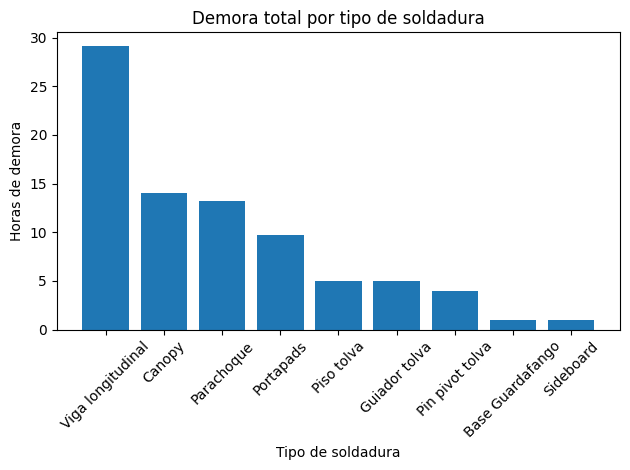

In [3]:
task = df.groupby("Tarea")["Demora"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(task.index, task.values)
plt.title("Demora total por tipo de soldadura")
plt.xlabel("Tipo de soldadura")
plt.ylabel("Horas de demora")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

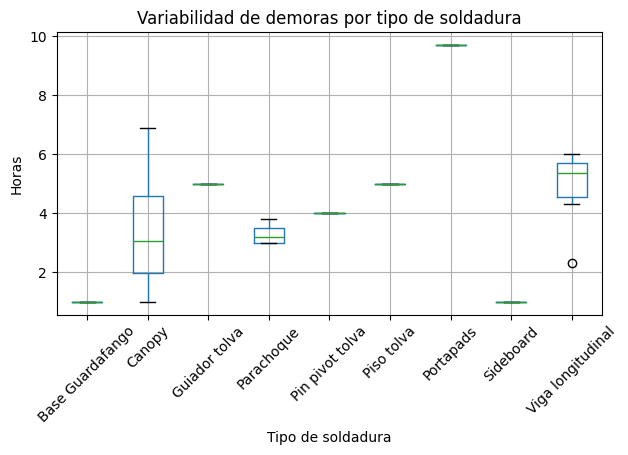

In [4]:
plt.figure()
df.boxplot(column="Demora", by="Tarea")
plt.title("Variabilidad de demoras por tipo de soldadura")
plt.suptitle("")
plt.xlabel("Tipo de soldadura")
plt.ylabel("Horas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

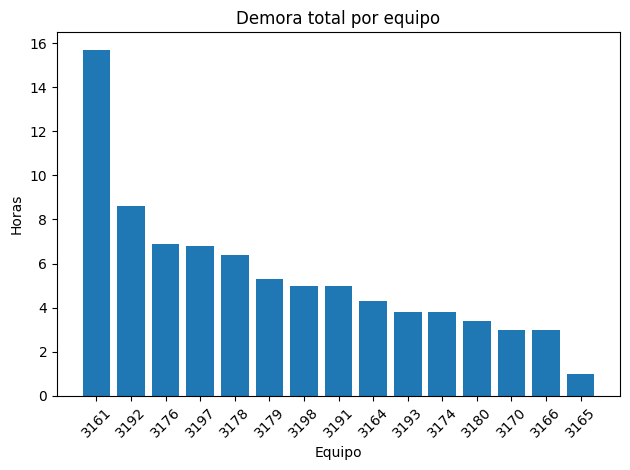

In [5]:
equipos = df.groupby("Equipo")["Demora"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(equipos.index.astype(str), equipos.values)
plt.title("Demora total por equipo")
plt.xlabel("Equipo")
plt.ylabel("Horas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

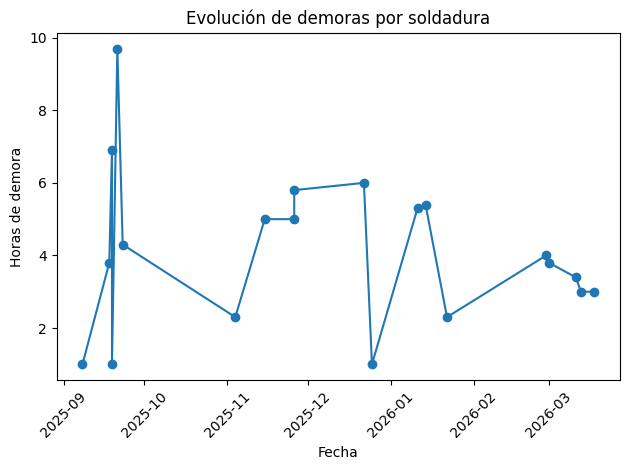

In [6]:
df_sorted = df.sort_values("Fecha")

plt.figure()
plt.plot(df_sorted["Fecha"], df_sorted["Demora"], marker='o')
plt.title("Evolución de demoras por soldadura")
plt.xlabel("Fecha")
plt.ylabel("Horas de demora")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

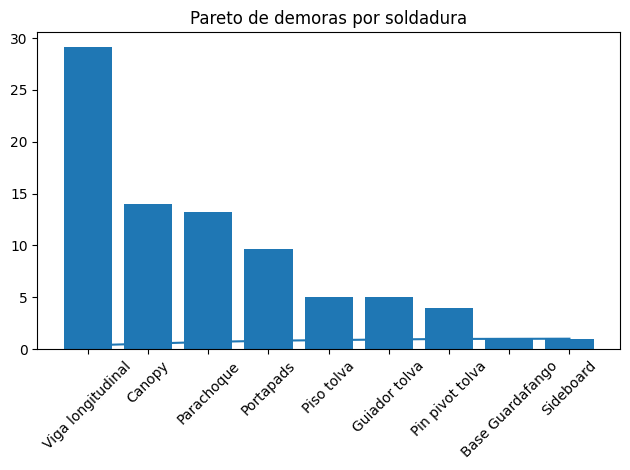

In [7]:
task_sorted = task.sort_values(ascending=False)
cum = task_sorted.cumsum() / task_sorted.sum()

plt.figure()
plt.bar(task_sorted.index, task_sorted.values)
plt.plot(task_sorted.index, cum.values)

plt.title("Pareto de demoras por soldadura")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

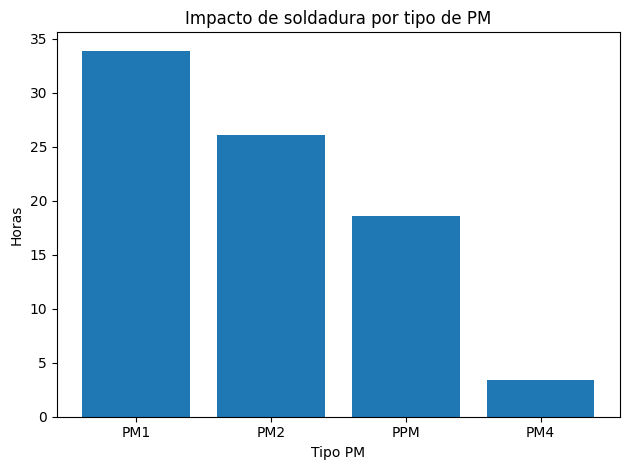

In [8]:
pm = df.groupby("Tipo_PM")["Demora"].sum().sort_values(ascending=False)

plt.figure()
plt.bar(pm.index, pm.values)
plt.title("Impacto de soldadura por tipo de PM")
plt.xlabel("Tipo PM")
plt.ylabel("Horas")
plt.tight_layout()
plt.show()

PROMEDIO DE HORAS DE DEMORA POR PM:

Tipo_PM
PM2    4.3500
PM1    4.2375
PPM    3.7200
PM4    3.4000
Name: Demora, dtype: float64


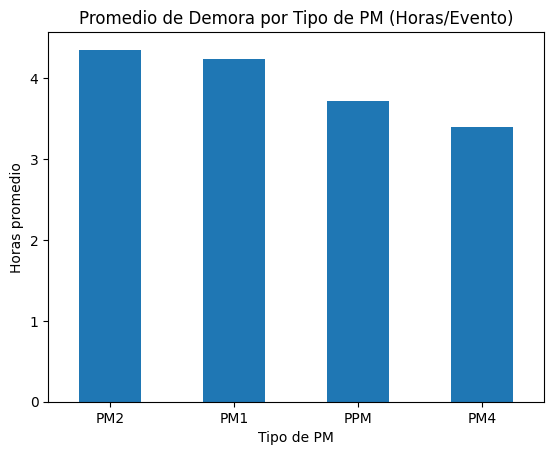

In [9]:
# Promedio de demora por tipo de PM
promedio_pm = df.groupby("Tipo_PM")["Demora"].mean().sort_values(ascending=False)

print("PROMEDIO DE HORAS DE DEMORA POR PM:\n")
print(promedio_pm)

# Gráfico
import matplotlib.pyplot as plt

plt.figure()
promedio_pm.plot(kind="bar")
plt.title("Promedio de Demora por Tipo de PM (Horas/Evento)")
plt.xlabel("Tipo de PM")
plt.ylabel("Horas promedio")
plt.xticks(rotation=0)
plt.show()

In [10]:
# Estadísticos por tipo de trabajo (Soldadura / Tarea)
stats = df.groupby("Tarea")["Demora"].agg(["count","mean","std","min","max"]).sort_values(by="std", ascending=False)

print(stats)

                   count  mean       std  min  max
Tarea                                             
Canopy                 4  3.50  2.539029  1.0  6.9
Viga longitudinal      6  4.85  1.380942  2.3  6.0
Parachoque             4  3.30  0.382971  3.0  3.8
Base Guardafango       1  1.00       NaN  1.0  1.0
Guiador tolva          1  5.00       NaN  5.0  5.0
Pin pivot tolva        1  4.00       NaN  4.0  4.0
Piso tolva             1  5.00       NaN  5.0  5.0
Portapads              1  9.70       NaN  9.7  9.7
Sideboard              1  1.00       NaN  1.0  1.0


In [13]:
# Estadísticos por tarea
stats = df.groupby("Tarea")["Demora"].agg(["mean","std"])

# Tiempo recomendado
stats["Tiempo_programado"] = (stats["mean"] + stats["std"]).round(0)

# Convertir a entero
stats["Tiempo_programado"] = stats["Tiempo_programado"].astype(int)

# 🔥 ORDENAR DE MAYOR A MENOR
stats = stats.sort_values(by="Tiempo_programado", ascending=False)

print(stats[["Tiempo_programado"]])

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [16]:
# Estadísticos por tarea
stats = df.groupby("Tarea")["Demora"].agg(["mean","std"])

# Renombrar columnas
stats = stats.rename(columns={
    "mean": "Tiempo_anterior",
    "std": "Desviacion"
})

# Reemplazar NaN por 0 (por seguridad)
stats["Desviacion"] = stats["Desviacion"].fillna(0)

# Tiempo programado
stats["Tiempo_programado"] = (stats["Tiempo_anterior"] + stats["Desviacion"]).round(0).astype(int)

# Redondeo visual
stats["Tiempo_anterior"] = stats["Tiempo_anterior"].round(1)
stats["Desviacion"] = stats["Desviacion"].round(1)

# 🔥 FILTRAR SOLO LOS QUE TIENEN DESVIACIÓN (>0)
stats = stats[stats["Desviacion"] > 0]

# Ordenar de mayor a menor impacto
stats = stats.sort_values(by="Tiempo_programado", ascending=False)

print(stats)

                   Tiempo_anterior  Desviacion  Tiempo_programado
Tarea                                                            
Canopy                         3.5         2.5                  6
Viga longitudinal              4.9         1.4                  6
Parachoque                     3.3         0.4                  4
